  # Detecting profiles in a population using K-modes clustering on qualitative variables

### Add kmodes library to pip environment if missing

* Open a terminal and activate your data analysis environment:

    -> my_venvs_activate data_analysis
* Install the missing package in the active environment:

    -> pip install kmodes

* Deactivate the environment when you have finished:

    -> my_venvs_deactivate


In [2]:
### Activate libraries that will be used in the notebook

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

import fanalysis.ca as fa 
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

import networkx as nx

import sqlite3 as sql

In [3]:
### Libraries used to import local modules

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [4]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [5]:
### Use this to reload the functions if modified
#print(reload(bl))
print(reload(cf))  

<module 'cluster_functions' from '/home/ministers/da5_data/cluster_functions.py'>


In [6]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.


The data was prepared and exported in the [da5_MCA]() notebook: "Prepare file for cluster analysis".




In [7]:
file_address='da5-MCA-cluster.csv'
df_pm = pd.read_csv(file_address)
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,...,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_sec1,fk_person,codedSecOccupation,codedSecparty
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,...,1911.0,1907-1926,355,politico,sindacalista,mancante,Partito Socialista Italiano,355,sindacalista,Sinistra/Centro Sinistra
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,...,1907.0,1907-1926,461,politico,diplomatico,mancante,Partito Repubblicano Italiano,461,diplomatico,Sinistra/Centro Sinistra
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,...,1909.0,1907-1926,331,politico,mancante,mancante,Partito Popolare Italiano,331,mancante,Centro


In [8]:
### Inspect the dataframe and 
# notably if there are missing values
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   reg_name            561 non-null    object 
 10  reg_istat_code_num  561 non-null    float64
 11  reg_istat_code      561 non-null    float64
 12  coded_Region        561 non-null    object 
 13  activityYear        561 non-null    float64
 14  periodsActivity     561 non-null    object 
 15  pk_person_features  561 non-null    int64  
 16  occupati

In [9]:
### Use this in Noto to keep seeing all dataframe columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Reset to default settings if needed later
pd.reset_option('display.max_columns')

## Inspect the distribution of the variables

As mentioned above, the data was prepared in a former notebook. 

The variables have already been coded and limited to a reasonable number of categories. The number of categories depends, of course, on the research questions.

In [10]:
### Group and count: gender
# This variable creates a significant divide
df_count = df_pm.groupby('gender').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



         number
gender         
maschio     502
femmina      59


In [11]:
### Group and count: main occupation
# This variable creates a significant divide
df_count = df_pm.groupby('occupation_main').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                 number
occupation_main        
politico            552
mancante              9


In [12]:
### Group and count: country
df_count = df_pm.groupby('coded_Region').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:70])

              number
coded_Region        
Nord             257
Sud              177
Centro           127


In [ ]:
### Group and count: coded employer
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('codedSecparty').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:70])

In [ ]:
### Group and count: activity periods
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('periodsActivity').size()
df_count = pd.DataFrame(df_count.sort_index())
df_count.columns=['number']
print(df_count.iloc[:50])

## Cluster


### K-Modes clustering method

K-modes clustering is an unsupervised machine learning algorithm designed specifically for categorical data. It is an extension of the [K-means clustering algorithm](https://en.wikipedia.org/wiki/K-means_clustering), which works only with numerical data.

While K-means calculates the mean of data points to find cluster centers (centroids) and uses Euclidean distance (i.e.  linear distances in the geometric space), K-modes adapts this process for categories:
* It uses the mode of the data points in a cluster (the most frequent category) to define the cluster center, rather than the arithmetic mean.
* Simple Matching Distance: It measures dissimilarity between data points by counting the number of mismatched categories (e.g., if two people have different colors, the distance increases by 1), rather than calculating geometric distance.
* Frequency-based Updates: The algorithm iteratively updates cluster modes based on the frequency of categories within each cluster.

[GitHub repository documentation of K-Modes](https://github.com/nicodv/kmodes)


### Choice of the variables

We have to decide which qualitative variables we will use for clustering and experiment with different situations.

&nbsp;

The approach we will test here is to use four basic features of the population: gender, country of origin, secondary (a more precise occupation then physicist/astronomers) and employer class, in order to create clusters.

We exclude the 'generation of activity' variable when clustering, but use it to situate the cluster within the flow of time, and to check whether some profiles are specific to a particular moment in time.

Also, in a first test, we also used the main occupation variable for clustering but this appeared to be too dominant and was hiding more interesting phenomena: cf. this [representation of the clusters](images/kmodes_clusters_with_main_occupation.png) using the main occupation (astronomy/physics). 

We therefore exclude it from clustering and use it to inspect if some clusters are more specific to a main discipline



In [14]:
### Data to be clustered

categorical_columns=['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']
data_cat = df_pm[categorical_columns].values
print(data_cat[:5])

[['maschio' 'Nord' 'sindacalista' 'Sinistra/Centro Sinistra']
 ['maschio' 'Centro' 'diplomatico' 'Sinistra/Centro Sinistra']
 ['maschio' 'Nord' 'mancante' 'Centro']
 ['maschio' 'Nord' 'avvocato' 'Destra/Centro Destra']
 ['maschio' 'Nord' 'avvocato' 'Sinistra/Centro Sinistra']]


### Determine Optimal Clusters (Elbow Method based on Cost)

N.B.: ou can SKIP this part and directly use 16 and 32 clusters or other multiples of the number of your periods.

&nbsp;

In this part we explore different numbers of clusters in order to discover those that express better the diversity of the population, and the relation to time.

In K-Modes, the cost is the sum of mismatches between every individual and their assigned cluster center (mode).

According to the Elbow Method, we add more clusters as long as the cost lowers significantly. 

You can experiment with different numbers of clusters, but this will take some time.

In [15]:
### 3. Determine Optimal Clusters (Elbow Method based on Cost)
# can take 20 minutes or more

### you can SKIP this step and directly test 16 and 32 clusters or other multiples of your periods

costs = []
k_range = range(16, 32) # Your specified range: (16, 41) ; (40, 57); (40,73)
for k in k_range:
    km = KModes(n_clusters=k, init='Huang', n_init=20, verbose=0)
    km.fit_predict(data_cat)
    costs.append(km.cost_)

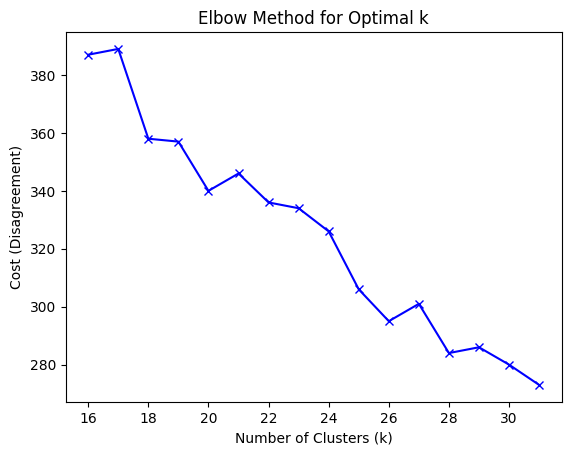

In [16]:
# Plot Elbow
plt.plot(k_range, costs, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost (Disagreement)')
plt.title('Elbow Method for Optimal k')
fig_address="doc_images/kmodes_elbow_40-72.jpg"
plt.savefig(fig_address, dpi=100, bbox_inches='tight')
plt.show()

### Centroids and cost in K-Modes


The machine learning process calculates the distance of each individual in a cluster from the one individual that was chosen as the centroid or mode in the cluster.

The cost (often called the Total Dissimilarity or Objective Function) is the sum of mismatches between every individual and their assigned cluster center (mode).

In [17]:
# Select k based on elbow (e.g., let's assume 30 for this run)
optimal_k = 32
# 8, cost: 9043.0;   
# 15, cost: 7890.0;  
# 16, cost: 7719.0;
# 21, cost : 7268.0.0 or 7252 (ML, not only the same )
# 32, cost: 6434.0
# 40, cost: 5953.0
# 44, cost: 5635.0
# 48, cost : 5704.0
# 54, cost : 5342.0
# 64, cost: 4921.0


# 4. Fit Final Model
km_final = KModes(n_clusters=optimal_k, init='Huang', n_init=20, verbose=0)

### We insert here the id of the cluster into a new column of the original dataframe
# The index order is the same, it works
df_pm['cluster'] = km_final.fit_predict(data_cat)
print(km_final.cost_)

267.0


In [18]:
### Inspect the cluster id number at the end of the rows
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,...,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_sec1,fk_person,codedSecOccupation,codedSecparty,cluster
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,...,1907-1926,355,politico,sindacalista,mancante,Partito Socialista Italiano,355,sindacalista,Sinistra/Centro Sinistra,4
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,...,1907-1926,461,politico,diplomatico,mancante,Partito Repubblicano Italiano,461,diplomatico,Sinistra/Centro Sinistra,22
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,...,1907-1926,331,politico,mancante,mancante,Partito Popolare Italiano,331,mancante,Centro,10


### Centroids (modes) and frequencies

Centroids in each cluster are the mode that is at the center of the population. Individuals in the same cluster but with different categories have some distance from this point.

We explore here the features of the 'central' individuals and what the other are.

In [19]:
### Get the centroids of the clusters
columns = ['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']
centroids_array = km_final.cluster_centroids_
centroid_df = pd.DataFrame(centroids_array, 
                           columns=columns)
centroid_df['cluster']=centroid_df.index
print(len(centroid_df))
centroid_df.head()

32


,gender,coded_Region,codedSecOccupation,codedSecparty,cluster
0,maschio,Sud,mancante,Sinistra/Centro Sinistra,0
1,maschio,Centro,professore,Centro,1
2,maschio,Sud,giurista,indipendente,2
3,femmina,Centro,mancante,Sinistra/Centro Sinistra,3
4,maschio,Nord,mancante,Sinistra/Centro Sinistra,4


In [20]:
### size of the clusters
dfg = pd.DataFrame(df_pm.groupby(by=['cluster']).size())
dfg.columns=['number_in_cl']
dfg.sort_values(by='number_in_cl', ascending=False).head()

,number_in_cl
cluster,
4,56
7,50
0,48
6,47
10,40


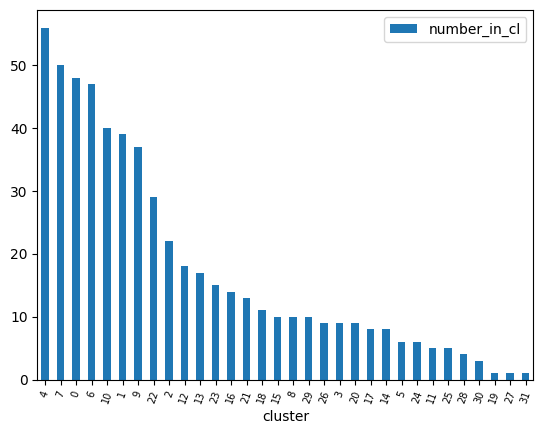

In [21]:
### 
c = dfg.sort_values(by='number_in_cl', ascending=False).plot(kind='bar')
c.tick_params(axis='x', labelsize=7, rotation=70)

In [22]:
print(dfg.number_in_cl.describe())

count    32.000000
mean     17.531250
std      16.337142
min       1.000000
25%       6.000000
50%      10.000000
75%      23.750000
max      56.000000
Name: number_in_cl, dtype: float64


#### Inspect frequency of individuals identical with centroid

In [23]:
### this dataframe contains only rows that are identical with the centroid in each cluster
merged_df = df_pm.merge(centroid_df, on=['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty', 'cluster'], how='inner')

In [24]:
### Persons with centroid value in proportion to population

# only persons identical to centroids of their cluster
print(len(merged_df))

# all the persons
print(len(df_pm))

# frequency
print(str(round((len(merged_df)/len(df_pm)*100),1))+' %')


298
561
53.1 %


In [25]:
### Count per cluster how many rows same as centroid
dfcen = pd.DataFrame(merged_df.groupby(by=['cluster']).size())
dfcen.columns=['n_centroid']
dfcen.sort_values(by='n_centroid', ascending=False).head()

,n_centroid
cluster,
10,40
6,31
7,19
0,19
12,18


#### Inspection of features

In [26]:
dfgf = pd.DataFrame(df_pm[df_pm.gender=='femmina'].groupby(by=['cluster']).size())
dfgf.columns=['number_f']
(print(dfgf.sort_values(by='number_f', ascending=False).iloc[:30]))

         number_f
cluster          
29             10
3               9
20              9
5               6
7               5
11              5
0               4
18              3
8               2
1               2
2               1
15              1
19              1
24              1


In [27]:
### Group and count countries in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'reg_name']).size()).reset_index()
result_df.columns=['cluster','coded_Region','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])
result_df.head()


# aggregated countries per cluster
dfg_country = result_df.groupby('cluster')[['coded_Region', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_country['countries_list'] = dfg_country.aggregated_data.apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_country=dfg_country.drop(columns=['cluster','aggregated_data'])


with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_country.head())

,countries_list
0,"Campania: 13, Sicilia: 12, Calabria: 9, Puglia: 9, Molise: 3"
1,"Lazio: 20, Marche: 7, Campania: 5, Toscana: 3, Umbria: 2"
2,"Campania: 14, Puglia: 3, Sardegna: 3, Abruzzo: 1, Sicilia: 1"
3,"Lazio: 6, Toscana: 2, Umbria: 1"
4,"Lombardia: 20, Piemonte: 12, Emilia-Romagna: 7, Liguria: 7, Veneto: 5"


In [28]:
### Group and count occupations in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'codedSecOccupation']).size()).reset_index()
result_df.columns=['cluster','codedSecOccupation','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])


# aggregated occupations per cluster
dfg_occupation = result_df.groupby('cluster')[['codedSecOccupation', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_occupation['occ_list'] = dfg_occupation['aggregated_data'].apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_occupation=dfg_occupation.drop(columns=['cluster','aggregated_data'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_occupation.head())


,occ_list
0,"mancante: 26, avvocato: 7, economista: 3, sindacalista: 3, giurista: 2"
1,"professore: 24, giornalista: 4, diplomatico: 2, medico: 2, economista: 1"
2,"giurista: 7, economista: 3, giornalista: 3, avvocato: 2, professore: 2"
3,"mancante: 6, accademico: 1, giornalista: 1, professore: 1"
4,"mancante: 18, partigiano: 8, professore: 7, economista: 5, giornalista: 4"


In [29]:
### Group and count employer classes in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'codedSecparty']).size()).reset_index()
result_df.columns=['cluster','codedSecparty','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])


# aggregated occupations per cluster
dfg_empl = result_df.groupby('cluster')[['codedSecparty', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_empl['party_list'] = dfg_empl['aggregated_data'].apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_empl=dfg_empl.drop(columns=['cluster','aggregated_data'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_empl.head())


,party_list
0,"Sinistra/Centro Sinistra: 44, Destra/Centro Destra: 3, indipendente: 1"
1,"Centro: 28, Sinistra/Centro Sinistra: 5, indipendente: 4, Destra/Centro Destra: 2"
2,"indipendente: 21, Centro: 1"
3,"Sinistra/Centro Sinistra: 5, Centro: 2, Destra/Centro Destra: 2"
4,Sinistra/Centro Sinistra: 56


#### Join and inspect

Aggregating the former tables and counts allows to inspect the clusters and identifying the structuring elements of the clusters 

In [30]:
### Join the different dataframes using the default joining on indexes
# If an error appears in joining, restart the whole process from cenroid_df onward

centroid_df=centroid_df.join(dfg)
centroid_df=centroid_df.join(dfcen)
centroid_df=centroid_df.join(dfgf).fillna(0)
centroid_df['number_f'] = centroid_df['number_f'].astype(int)
centroid_df['prop_f'] = centroid_df.apply(lambda x: (x['number_f']/x['number_in_cl']), axis=1)
centroid_df['prop_f']= centroid_df['prop_f'].round(2)

centroid_df=centroid_df.join(dfg_country)
centroid_df=centroid_df.join(dfg_occupation)
centroid_df=centroid_df.join(dfg_empl)

In [31]:
a = """
# Align all columns to the left
df.style.set_properties(**{'text-align': 'left'})

# Align specific columns to the left
df.style.set_properties(subset=['column_name_1', 'column_name_2'], **{'text-align': 'left'})

# Align only string columns to the left, keep numbers right (common practice)
df.style.set_properties(**{'text-align': 'left'}, subset=df.select_dtypes(include=['object', 'string']).columns)
"""

In [32]:
centroid_df['label'] = centroid_df.apply(
    lambda x: str(x.name) + "_" + "_".join(x[['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']].astype(str)), 
    axis=1
)
centroid_df.head(1)

,gender,coded_Region,codedSecOccupation,codedSecparty,cluster,number_in_cl,n_centroid,number_f,prop_f,countries_list,occ_list,party_list,label
0,maschio,Sud,mancante,Sinistra/Centro Sinistra,0,48,19,4,0.08,"Campania: 13, Sicilia: 12, Calabria: 9, Puglia...","mancante: 26, avvocato: 7, economista: 3, sind...","Sinistra/Centro Sinistra: 44, Destra/Centro De...",0_maschio_Sud_mancante_Sinistra/Centro Sinistra


In [33]:
centroid_df['prop_centr']=centroid_df.apply(lambda x : x['n_centroid']/x['number_in_cl'], axis=1).round(2)

In [34]:
centroid_df=centroid_df[['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty',
                            'cluster', 'number_in_cl', 
                              'n_centroid', 'prop_centr',
                              'number_f', 'prop_f', 'label',
                              'countries_list', 'occ_list', 
                               'party_list']]

In [35]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(centroid_df.sort_values(by='prop_centr', ascending=False).style.set_properties(subset=['occ_list', 'countries_list'], **{'text-align': 'left'}))

,gender,coded_Region,codedSecOccupation,codedSecparty,cluster,number_in_cl,n_centroid,prop_centr,number_f,prop_f,label,countries_list,occ_list,party_list
12,maschio,Centro,mancante,Centro,12,18,18,1.000000,0,0.000000,12_maschio_Centro_mancante_Centro,"Lazio: 12, Toscana: 4, Marche: 1, Umbria: 1",mancante: 18,Centro: 18
13,maschio,Sud,avvocato,Centro,13,17,17,1.000000,0,0.000000,13_maschio_Sud_avvocato_Centro,"Sicilia: 6, Basilicata: 2, Campania: 2, Puglia: 2, Sardegna: 2",avvocato: 17,Centro: 17
14,maschio,Nord,professore,Centro,14,8,8,1.000000,0,0.000000,14_maschio_Nord_professore_Centro,"Emilia-Romagna: 2, Lombardia: 2, Veneto: 2, Liguria: 1, Trentino-Alto Adige/Südtirol: 1",professore: 8,Centro: 8
10,maschio,Nord,mancante,Centro,10,40,40,1.000000,0,0.000000,10_maschio_Nord_mancante_Centro,"Lombardia: 14, Veneto: 8, Emilia-Romagna: 7, Friuli-Venezia Giulia: 3, Liguria: 3",mancante: 40,Centro: 40
27,maschio,Nord,giurista,indipendente,27,1,1,1.000000,0,0.000000,27_maschio_Nord_giurista_indipendente,Liguria: 1,giurista: 1,indipendente: 1
26,maschio,Centro,mancante,Sinistra/Centro Sinistra,26,9,9,1.000000,0,0.000000,26_maschio_Centro_mancante_Sinistra/Centro Sinistra,"Toscana: 5, Lazio: 3, Marche: 1",mancante: 9,Sinistra/Centro Sinistra: 9
30,maschio,Centro,giurista,Sinistra/Centro Sinistra,30,3,3,1.000000,0,0.000000,30_maschio_Centro_giurista_Sinistra/Centro Sinistra,Lazio: 3,giurista: 3,Sinistra/Centro Sinistra: 3
19,femmina,Centro,mancante,indipendente,19,1,1,1.000000,1,1.000000,19_femmina_Centro_mancante_indipendente,Lazio: 1,mancante: 1,indipendente: 1
31,maschio,Nord,mancante,indipendente,31,1,1,1.000000,0,0.000000,31_maschio_Nord_mancante_indipendente,Veneto: 1,mancante: 1,indipendente: 1
16,maschio,Nord,economista,indipendente,16,14,12,0.860000,0,0.000000,16_maschio_Nord_economista_indipendente,"Lombardia: 6, Veneto: 3, Emilia-Romagna: 2, Lazio: 2, Piemonte: 1",economista: 14,indipendente: 14


In [39]:
pers_cluster=df_pm[['person_uri', 'cluster']]
pers_cluster.head()

,person_uri,cluster
0,http://www.wikidata.org/entity/Q3839099,4
1,http://www.wikidata.org/entity/Q463243,22
2,http://www.wikidata.org/entity/Q3771001,10
3,http://www.wikidata.org/entity/Q1242,7
4,http://www.wikidata.org/entity/Q3839683,21


### Is there a correspondence between clusters and generations

In [40]:
# 5. Validate against Generation (Unused Variable)
# Cross-tabulation : contingency_table
observed = pd.crosstab(df_pm['cluster'], df_pm['periodsActivity'])


In [41]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


In [42]:
expected=bl.bivariate_stats(observed)

Chi-square : 310.07 , dof : 155
p-value : 0.0
Inertia (Phi-square):  0.553
Cramer:  0.332


### CA

In [43]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,"Index([ 0, 1...ame='cluster')"
,col_labels,Index(['1907-...iodsActivity')
,stats,True


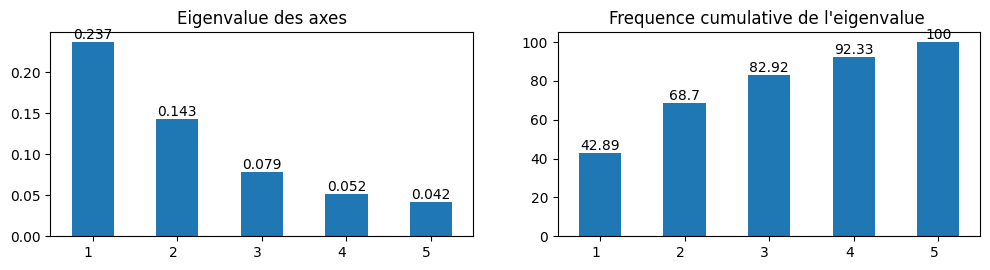

In [44]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

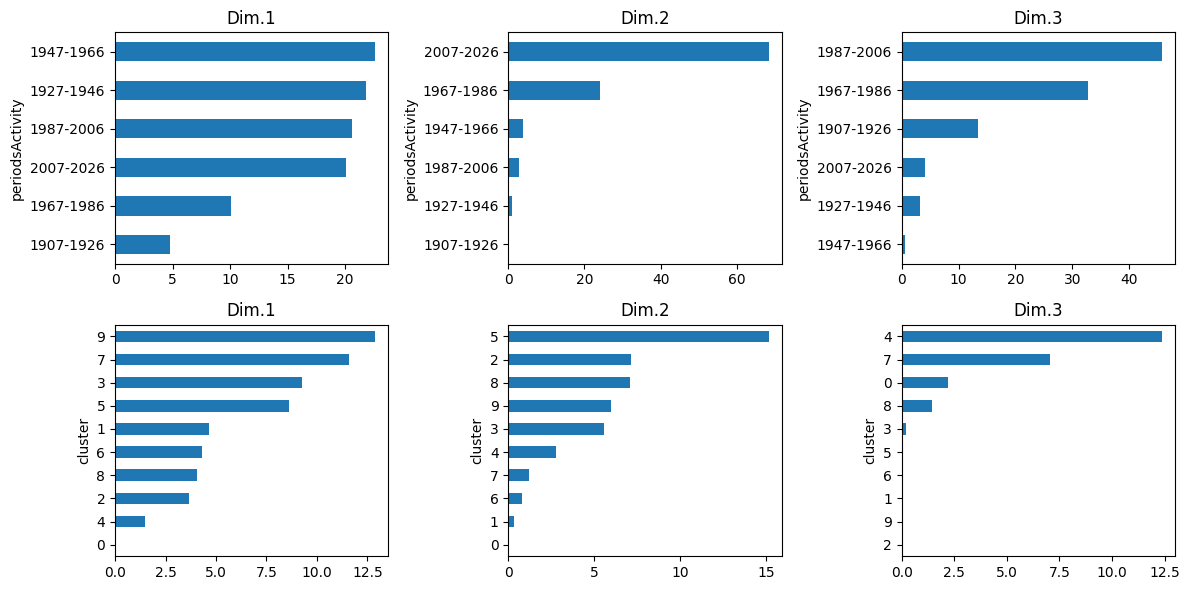

In [45]:
cal.dim_contributions(afc)

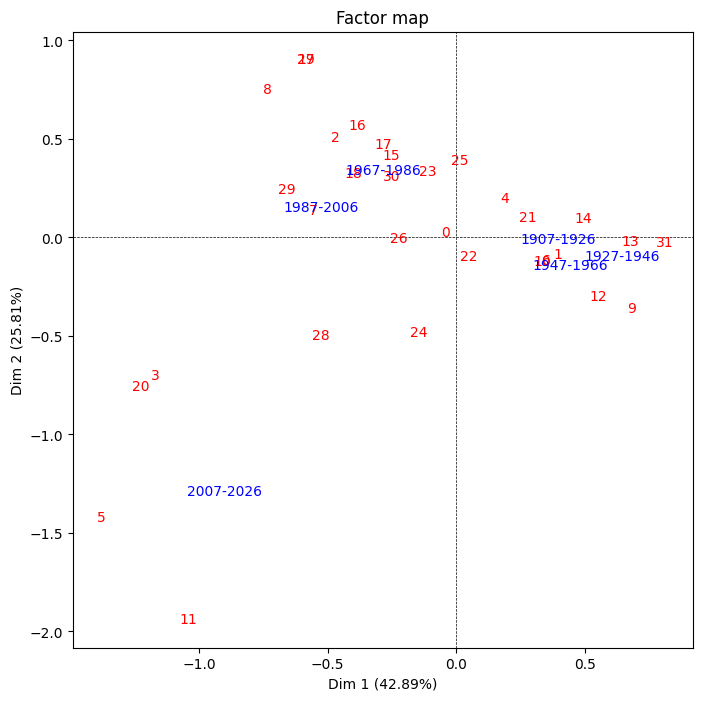

In [46]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(8,8))

In [47]:
# Represent dimension 3 and 4
# afc.mapping(num_x_axis=3,num_y_axis=4,figsize=(8,8))

### Inspection of the clusters

* Use the SQLite tables, cf. this [SQL queries document](../../documentation/wikidata/data-analysis/da5-explore-clusters.sql)
* Use the representation in form of a graph (cf. below)

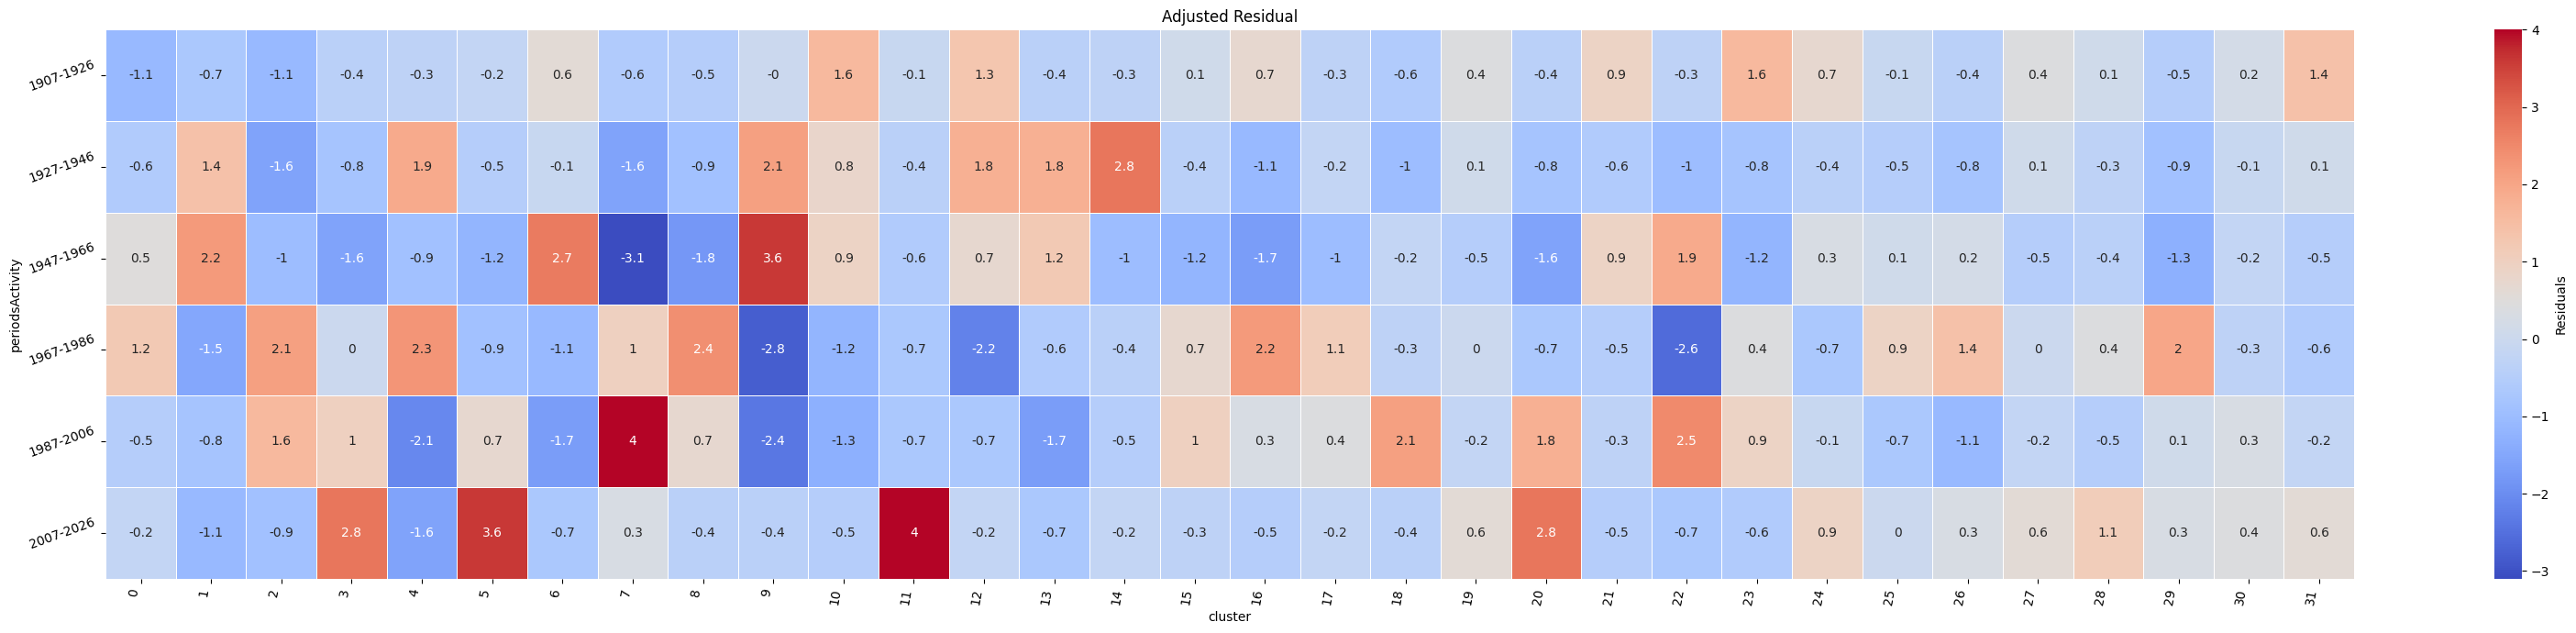

In [48]:
width= optimal_k
pp = bl.plot_chi2_residuals(observed.T, figsize=(optimal_k, 7))

In [51]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(centroid_df[['label','number_in_cl','n_centroid','number_f']])

,label,number_in_cl,n_centroid,number_f
0,0_maschio_Sud_mancante_Sinistra/Centro Sinistra,48,19,4
1,1_maschio_Centro_professore_Centro,39,5,2
2,2_maschio_Sud_giurista_indipendente,22,5,1
3,3_femmina_Centro_mancante_Sinistra/Centro Sinistra,9,3,9
4,4_maschio_Nord_mancante_Sinistra/Centro Sinistra,56,18,0
5,5_femmina_Sud_mancante_Centro,6,4,6
6,6_maschio_Sud_mancante_Centro,47,31,0
7,7_maschio_Nord_mancante_Destra/Centro Destra,50,19,5
8,8_maschio_Nord_imprenditore_Destra/Centro Destra,10,6,2
9,9_maschio_Nord_avvocato_Centro,37,13,0


# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    # Usiamo .to_html(index=False) per generare il codice pulito senza la colonna dei numeri di riga di pandas
    print(centroid_df[['label','number_in_cl','n_centroid','number_f']].to_html(index=False))

### Représenter les clusters sous forme de graphes ou d'images  


On exporte les clusters sous forme de graphe au format Gephi: gexf et on les importe dans Gephi LIte Online, où on peut améliorer la représentation et inspecter.




In [53]:
df_pm.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,...,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_sec1,fk_person,codedSecOccupation,codedSecparty,cluster
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,...,1907-1926,355,politico,sindacalista,mancante,Partito Socialista Italiano,355,sindacalista,Sinistra/Centro Sinistra,4
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,...,1907-1926,461,politico,diplomatico,mancante,Partito Repubblicano Italiano,461,diplomatico,Sinistra/Centro Sinistra,22


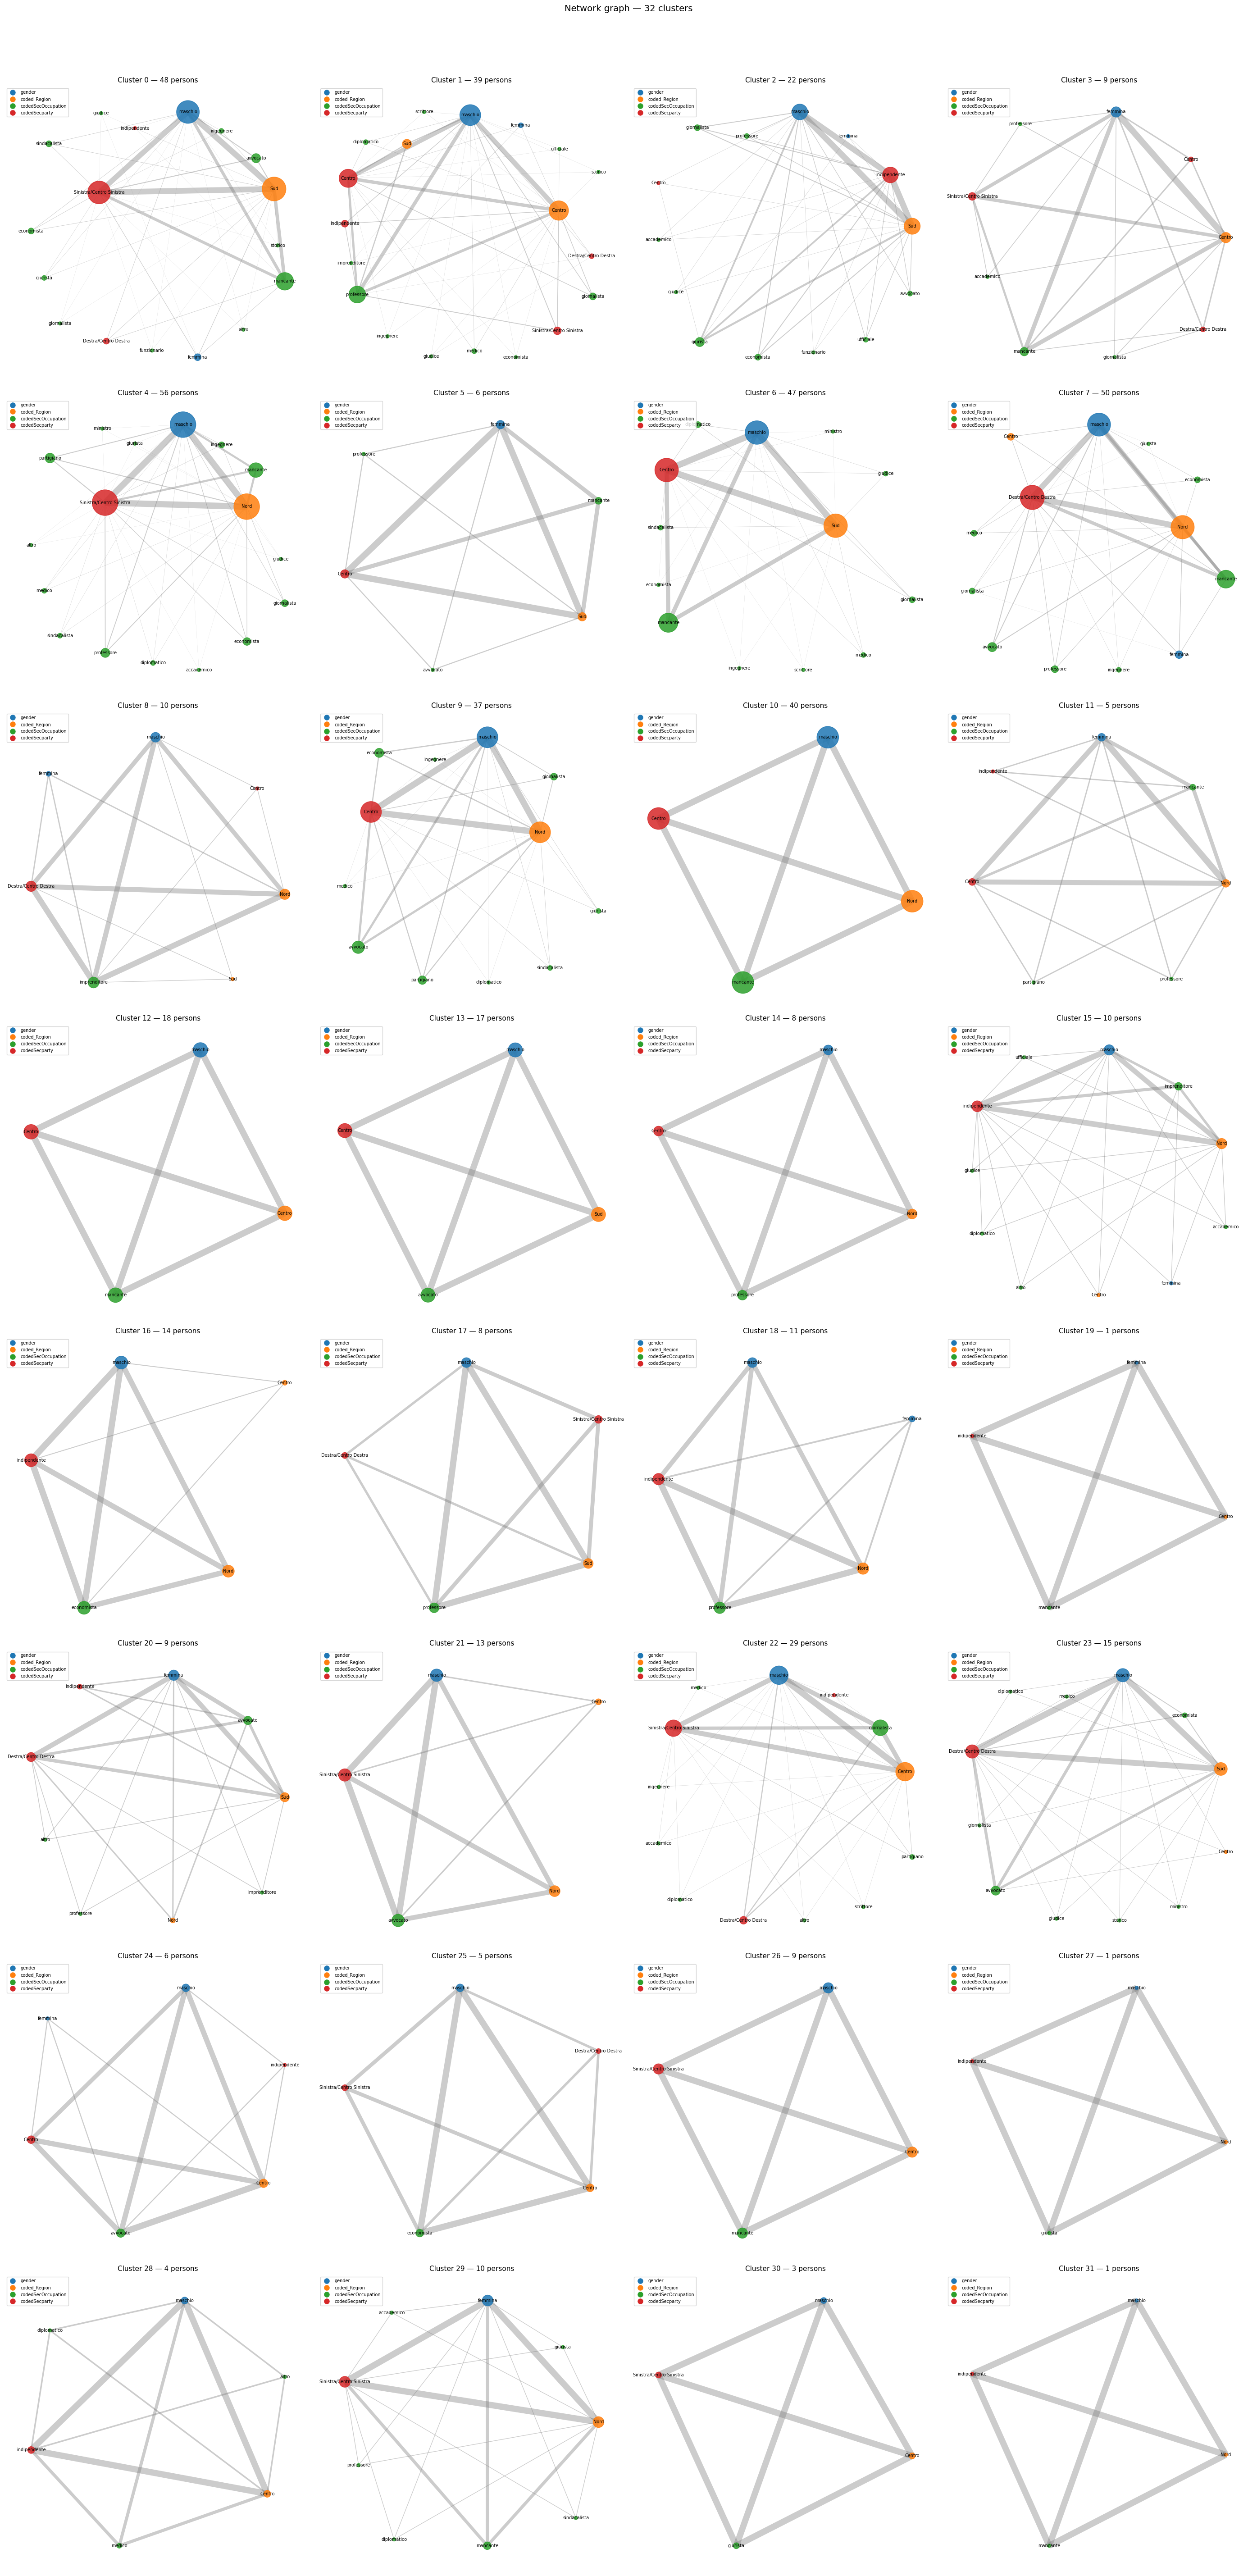

In [54]:
## On peut aussi créer des images, mais très larges si plusieur clusters
columns = ['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']
pict_address='images/kmodes_clusters_4_variables_44cl.png'
cf.plot_cluster_networks(df_pm, columns, optimal_k, 
        pict_address=pict_address)